In [1]:
# import numpy as np
import pickle
from glob import glob

import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.font_manager import FontProperties  # Import for custom fonts
from scipy.interpolate import interp1d
from sklearn.metrics import auc

# import seaborn as sns
from tqdm import tqdm

In [41]:
cris_metadata = pd.read_csv("accessory_files/cris_metadata.csv")


all_results = []
filepaths_list = sorted(glob("nested_cv_results/results_support_vector_machine*p_value.pkl"))
# filepaths_list = sorted(glob('nested_cv_results/results_logistic_regression*weighted.pkl'))
# filepaths_list = sorted(glob('nested_cv_results/results_random_forest*weighted.pkl'))
# filepaths_list = sorted(glob('nested_cv_results/results_k-nearest_neighbors*weighted.pkl'))

for path in tqdm(filepaths_list, desc="Loading results"):
    with open(path, "rb") as f:
        df = pickle.load(f)
        all_results.append(df)

# Concatenate into the final DataFrame
all_results_df = pd.concat(all_results, ignore_index=True)

# Replace 20000 with 17156 in the 'top_genes' column
all_results_df["top_genes"] = all_results_df["top_genes"].replace(20000, 16454)

print("Successfully consolidated all results.")
all_results_df

Loading results: 100%|██████████| 70/70 [00:00<00:00, 375.88it/s]


Successfully consolidated all results.


,feature,top_genes,fold,classifier,best_params,num_genes_used,misclassified_sample_ids,test_sample_ids,auc_full_model,fpr_full_model,tpr_full_model,precision_full_model,recall_full_model,classification_report_full_model,confusion_matrix_full_model,auc_per_cancer_type,roc_per_cancer_type,pr_per_cancer_type
0,fslr,10000,1,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",10000,"[EE88030, EE88040, EE88059, EE87802, EE87824, ...","[EE87979, EE87985, EE87988, EE87999, EE88025, ...",0.886364,"[0.0, 0.0, 0.0, 0.045454545454545456, 0.045454...","[0.0, 0.05, 0.5, 0.5, 0.6, 0.6, 0.8, 0.8, 0.85...","[0.47619047619047616, 0.4878048780487805, 0.5,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.95, 0.95...","{'0': {'precision': 0.7307692307692307, 'recal...","[[19, 3], [7, 13]]","{'Bile duct cancer': 0.9318181818181819, 'Brea...","{'Bile duct cancer': {'fpr': [0.0, 0.0, 0.1363...",{'Bile duct cancer': {'precision': [0.08333333...
1,fslr,10000,2,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",10000,"[EE87971, EE88024, EE88041, EE88042, EE88043, ...","[EE87971, EE87997, EE88020, EE88021, EE88024, ...",0.861364,"[0.0, 0.0, 0.0, 0.045454545454545456, 0.045454...","[0.0, 0.05, 0.55, 0.55, 0.6, 0.6, 0.7, 0.7, 0....","[0.47619047619047616, 0.4878048780487805, 0.5,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.95,...","{'0': {'precision': 0.8333333333333334, 'recal...","[[15, 7], [3, 17]]","{'Bile duct cancer': 0.6590909090909092, 'Brea...","{'Bile duct cancer': {'fpr': [0.0, 0.0, 0.6818...",{'Bile duct cancer': {'precision': [0.08333333...
2,fslr,10000,3,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",10000,"[EE87975, EE88032, EE88069, EE88090, EE88099, ...","[EE87975, EE87977, EE87992, EE88032, EE88047, ...",0.773243,"[0.0, 0.0, 0.0, 0.047619047619047616, 0.047619...","[0.0, 0.047619047619047616, 0.2857142857142857...","[0.5, 0.5121951219512195, 0.525, 0.53846153846...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.95238095...","{'0': {'precision': 0.6521739130434783, 'recal...","[[15, 6], [8, 13]]","{'Bile duct cancer': 0.873015873015873, 'Breas...","{'Bile duct cancer': {'fpr': [0.0, 0.0, 0.0476...","{'Bile duct cancer': {'precision': [0.125, 0.1..."
3,fslr,10000,4,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",10000,"[EE87991, EE88017, EE88028, EE88029, EE87792, ...","[EE87974, EE87984, EE87991, EE88004, EE88005, ...",0.895692,"[0.0, 0.0, 0.0, 0.047619047619047616, 0.047619...","[0.0, 0.047619047619047616, 0.4761904761904761...","[0.5, 0.525, 0.5384615384615384, 0.55263157894...","[1.0, 1.0, 1.0, 1.0, 1.0, 0.9523809523809523, ...","{'0': {'precision': 0.8947368421052632, 'recal...","[[17, 4], [2, 19]]","{'Bile duct cancer': 0.8412698412698413, 'Brea...","{'Bile duct cancer': {'fpr': [0.0, 0.0, 0.0476...","{'Bile duct cancer': {'precision': [0.125, 0.1..."
4,fslr,10000,5,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",10000,"[EE87998, EE88008, EE88010, EE88019, EE88033, ...","[EE87980, EE87990, EE87998, EE88008, EE88010, ...",0.827664,"[0.0, 0.0, 0.0, 0.047619047619047616, 0.047619...","[0.0, 0.047619047619047616, 0.2380952380952380...","[0.5, 0.5121951219512195, 0.525, 0.53846153846...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","{'0': {'precision': 0.75, 'recall': 0.71428571...","[[15, 6], [5, 16]]","{'Bile duct cancer': 0.6825396825396826, 'Brea...","{'Bile duct cancer': {'fpr': [0.0, 0.047619047...","{'Bile duct cancer': {'precision': [0.125, 0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,rcov,50,6,Support Vector Machine,"{'clf__C': 0.01, 'clf__kernel': 'linear'}",50,"[EE88057, EE88072, EE88126, EE88146, EE88170, ...","[EE88002, EE88003, EE88011, EE88014, EE88015, ...",0.795918,"[0.0, 0.0, 0.0, 0.047619047619047616, 0.047619...","[0.0, 0.047619047619047616, 0.1428571428571428...","[0.5, 0.5121951219512195, 0.525, 0.53846153846...","[1.0, 1.0, 1.0, 1.0, 1.0, 0.9523809523809523, ...","{'0': {'precision': 0.727

/tmp/ipykernel_2399/3232179529.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


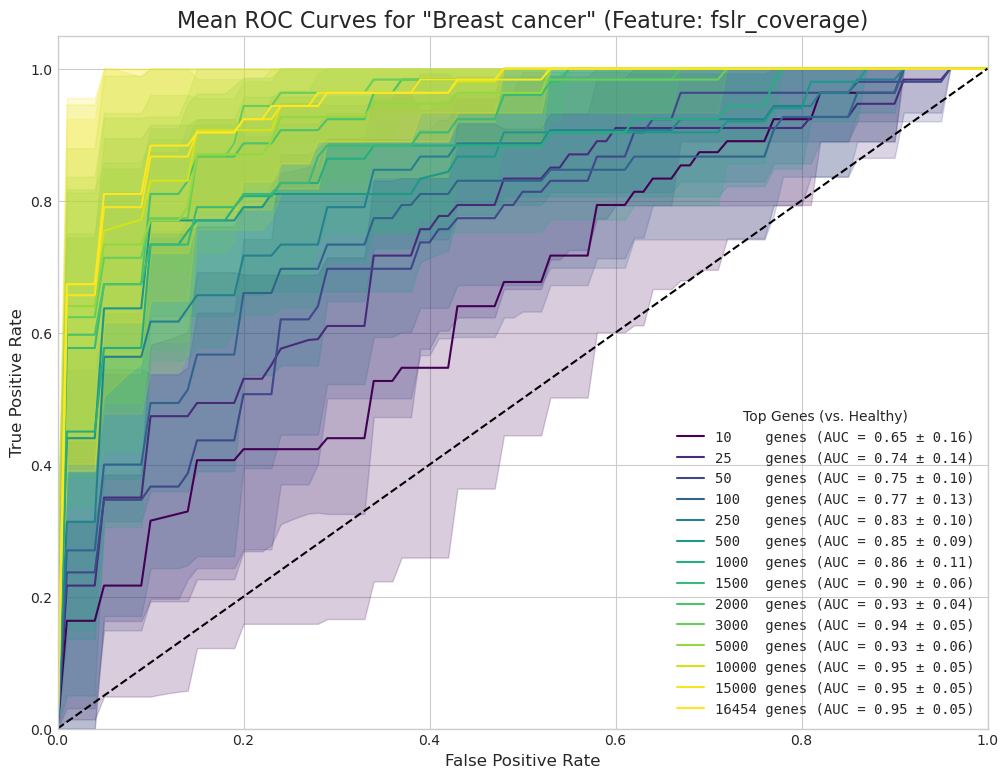

In [34]:
def plot_mean_roc_curves_by_cancer_type(results_df: pd.DataFrame, feature_name: str, cancer_type: str):
    """
    Plots the mean ROC curves for a specific feature AND a specific cancer type,
    with a color gradient for the number of genes.
    """

    # Filter for the specific feature and classifier
    feature_df = results_df[results_df["feature"] == feature_name].copy()
    # feature_df = feature_df[feature_df['classifier'] == 'Support Vector Machine']

    if feature_df.empty:
        print(f"No results found for feature: {feature_name}")
        return

    base_fpr = np.linspace(0, 1, 101)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 9))

    top_genes_values = sorted(feature_df["top_genes"].unique())
    norm = colors.LogNorm(vmin=min(top_genes_values) if top_genes_values else 1, vmax=max(top_genes_values) if top_genes_values else 1)
    cmap = cm.get_cmap("viridis")

    for n_genes in top_genes_values:
        group = feature_df[feature_df["top_genes"] == n_genes]

        tpr_list, auc_scores = [], []

        for _, row in group.iterrows():
            # Check if this cancer type was present in this fold's test set
            if cancer_type in row["roc_per_cancer_type"]:
                # Access the nested dictionary for the specific cancer type
                roc_data = row["roc_per_cancer_type"][cancer_type]
                auc_score = row["auc_per_cancer_type"][cancer_type]

                interp_func = interp1d(roc_data["fpr"], roc_data["tpr"], kind="linear")
                tpr_list.append(interp_func(base_fpr))
                auc_scores.append(auc_score)

        # If no data was found for this gene count (e.g., cancer type never in test set), skip
        if not tpr_list:
            continue

        mean_tprs = np.mean(tpr_list, axis=0)
        mean_tprs[0], mean_tprs[-1] = 0, 1
        mean_auc, std_auc = np.mean(auc_scores), np.std(auc_scores)

        color = cmap(norm(n_genes))

        # Create a padded string for the legend label
        label_text = f"{n_genes:<5} genes (AUC = {mean_auc:.2f} ± {std_auc:.2f})"

        ax.plot(base_fpr, mean_tprs, label=label_text, color=color)

        std_tprs = np.std(tpr_list, axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tprs, 1)
        tprs_lower = np.maximum(mean_tprs - std_tprs, 0)

        ax.fill_between(base_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

    mono_font = FontProperties(family="monospace")

    # Final plot formatting
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f'Mean ROC Curves for "{cancer_type}" (Feature: {feature_name})', fontsize=16)
    ax.grid(True)

    ax.legend(loc="lower right", prop=mono_font, title="Top Genes (vs. Healthy)")

    plt.show()


# --- Example Usage ---

# This map helps translate short names to the full names in your dataframe
CANCER_MAP = {"breast": "Breast cancer", "bileduct": "Bile duct cancer", "colorectal": "Colorectal cancer", "gastric": "Gastric cancer", "lung": "Lung cancer naive nsclc", "ovarian": "Ovarian cancer", "pancreatic": "Pancreatic cancer"}

# Ensure your 'all_results_df' is loaded before running this
# Plot the ROC curves specifically for Breast Cancer using the 'fslr' feature
if "all_results_df" in locals() and CANCER_MAP["breast"] in all_results_df["auc_per_cancer_type"].iloc[0]:
    plot_mean_roc_curves_by_cancer_type(all_results_df, feature_name="fslr_coverage", cancer_type=CANCER_MAP["breast"])
else:
    print("Please load 'all_results_df' and ensure it contains data for 'Breast cancer'.")

# Plot the results for all features and all cancer types
# for feature in all_results_df['feature'].unique():
#     for cancer in CANCER_MAP.values():
#         if cancer in all_results_df['auc_per_cancer_type'].iloc[0]:
#             plot_mean_roc_curves_by_cancer_type(all_results_df, feature_name=feature, cancer_type=cancer)
#         else:
#             print(f"No data for cancer type: {cancer} in the results.")

/tmp/ipykernel_2399/106297513.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


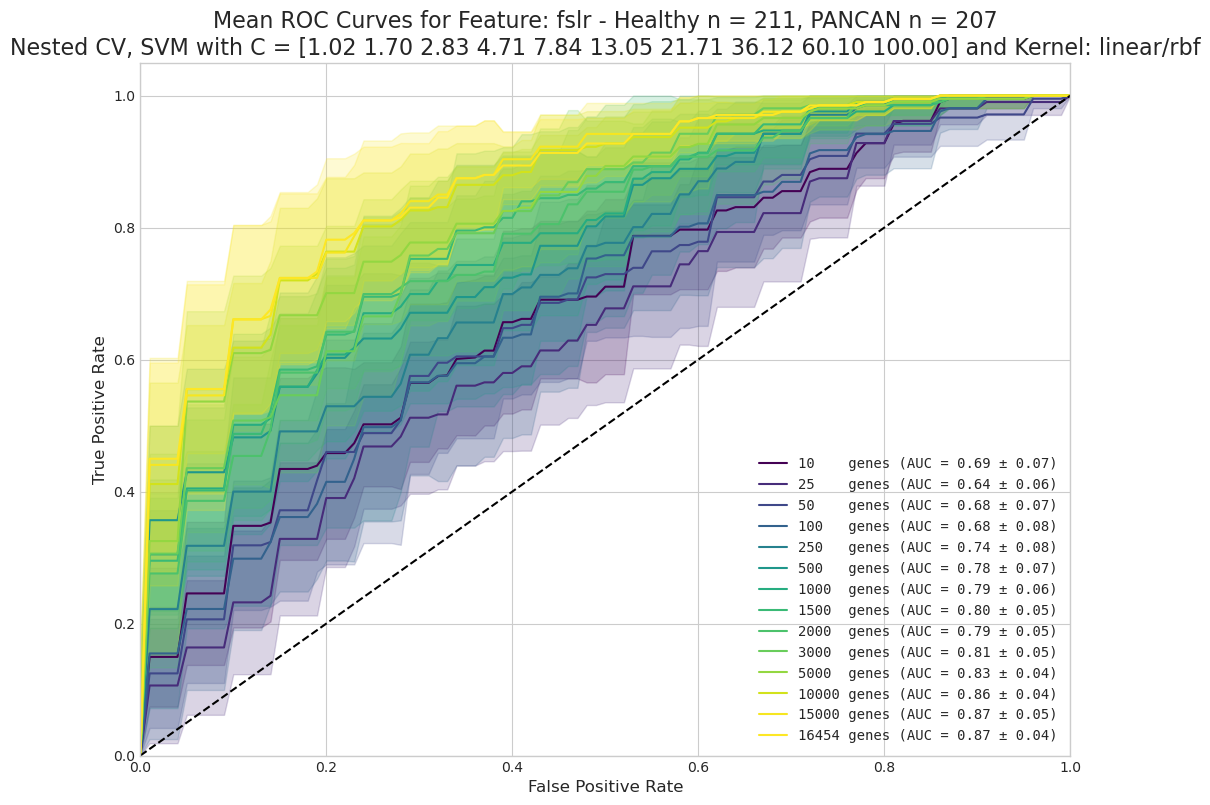

/tmp/ipykernel_2399/106297513.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


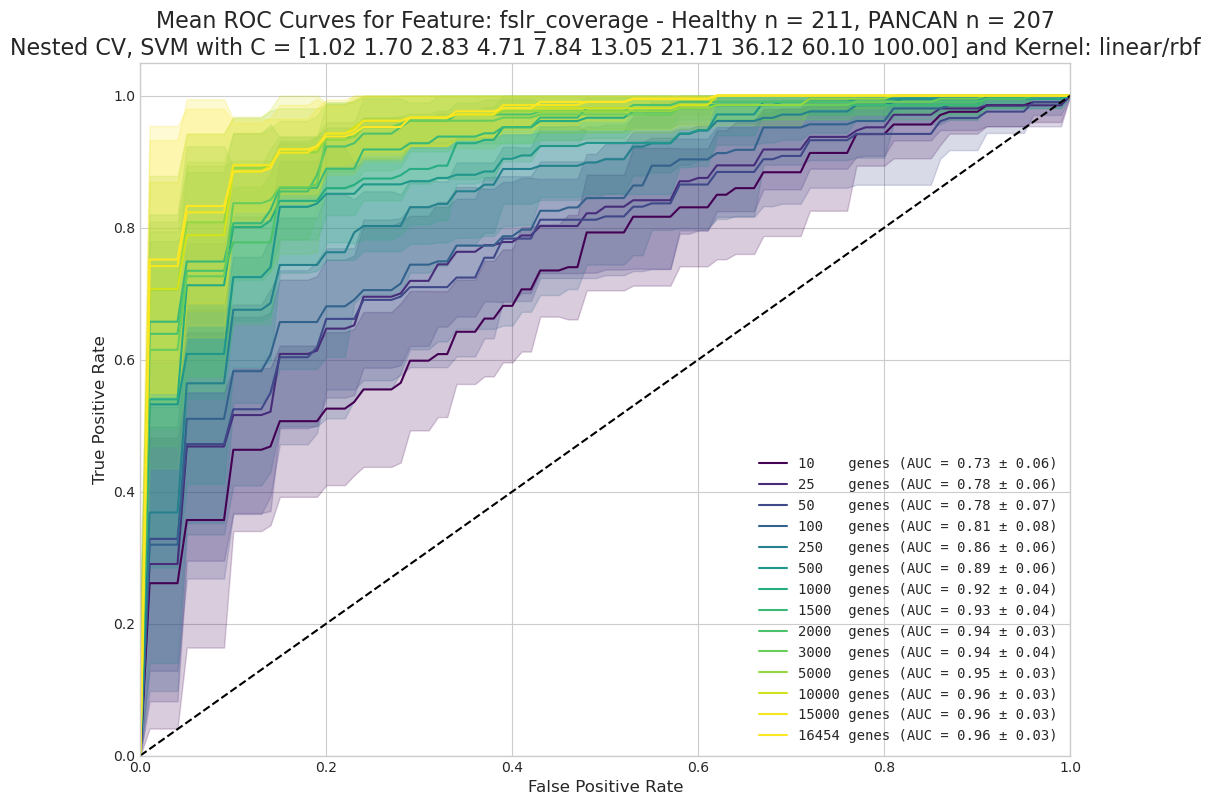

/tmp/ipykernel_2399/106297513.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


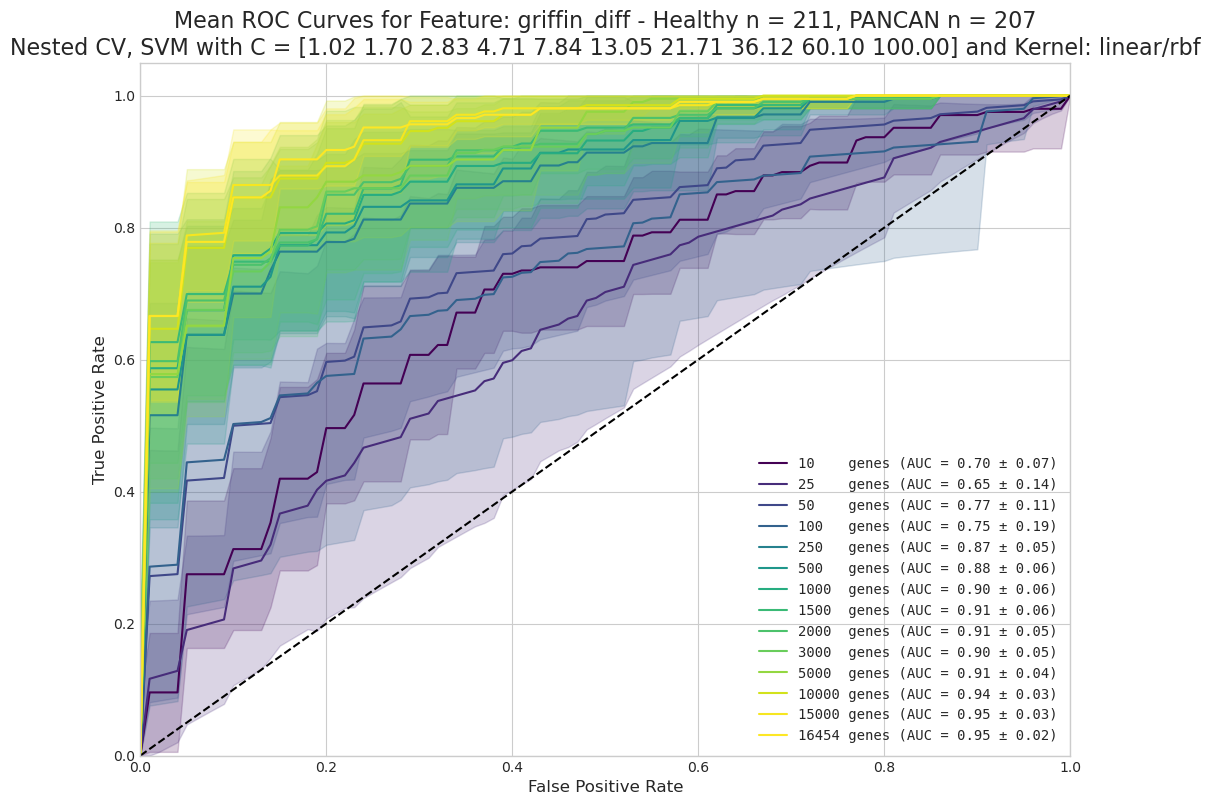

/tmp/ipykernel_2399/106297513.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


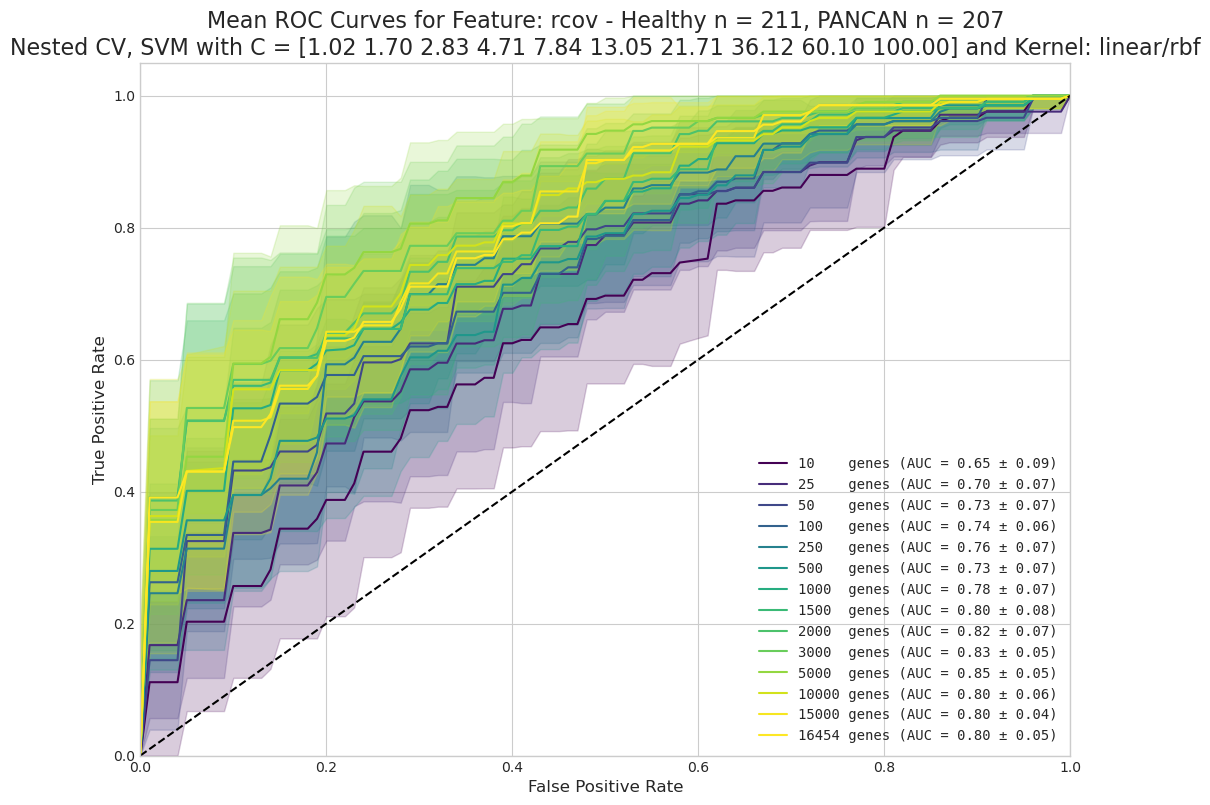

/tmp/ipykernel_2399/106297513.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


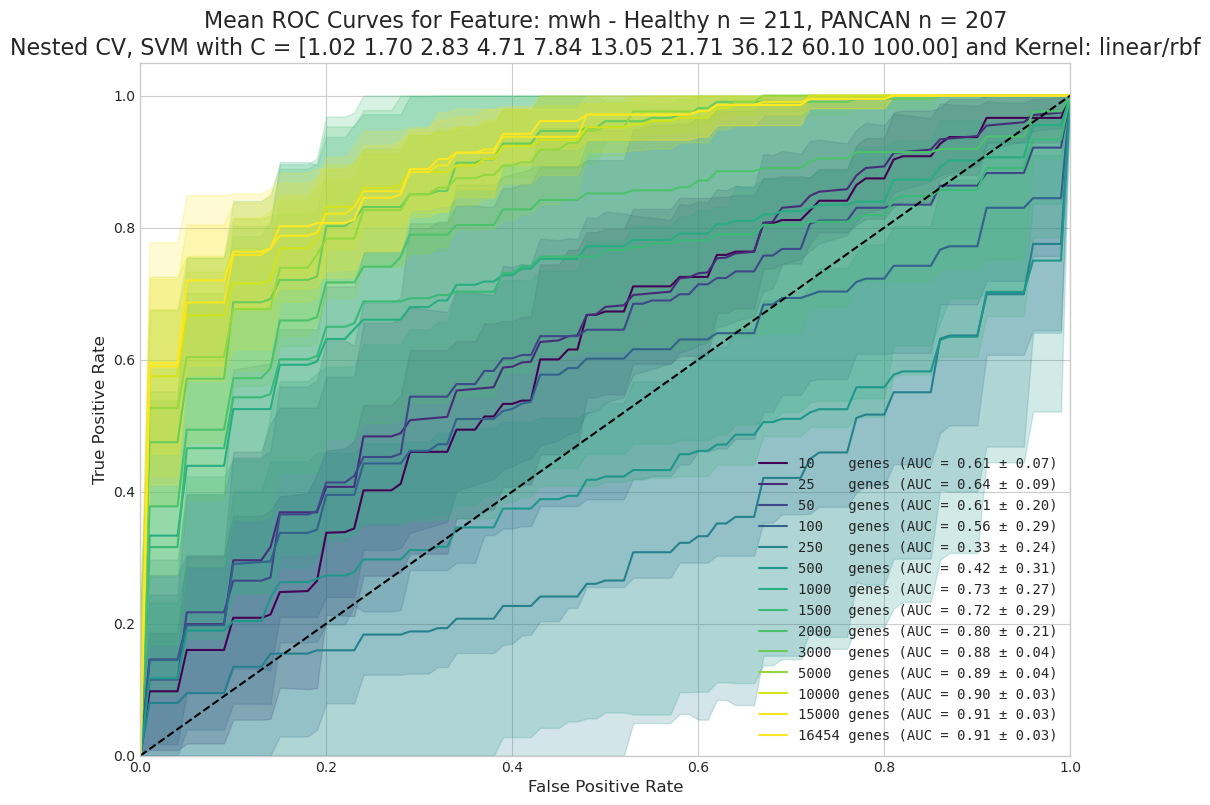

In [42]:
def plot_mean_roc_curves_by_gene_count(results_df: pd.DataFrame, feature_name: str):
    """
    Plots the mean ROC curves for a given feature, with a color gradient
    and a right-aligned legend.
    """

    feature_df = results_df[results_df["feature"] == feature_name].copy()

    feature_df = feature_df[feature_df["classifier"] == "Support Vector Machine"]
    # feature_df = feature_df[feature_df['classifier'] == 'K-Nearest Neighbors']

    if feature_df.empty:
        print(f"No results found for feature: {feature_name}")
        return

    base_fpr = np.linspace(0, 1, 101)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 9))

    top_genes_values = sorted(feature_df["top_genes"].unique())
    norm = colors.LogNorm(vmin=min(top_genes_values), vmax=max(top_genes_values))
    cmap = cm.get_cmap("viridis")

    for n_genes in top_genes_values:
        group = feature_df[feature_df["top_genes"] == n_genes]

        tpr_list, auc_scores = [], []
        for _, row in group.iterrows():
            interp_func = interp1d(row["fpr_full_model"], row["tpr_full_model"], kind="linear")
            tpr_list.append(interp_func(base_fpr))
            auc_scores.append(row["auc_full_model"])

        mean_tprs = np.mean(tpr_list, axis=0)
        mean_tprs[0], mean_tprs[-1] = 0, 1
        mean_auc, std_auc = np.mean(auc_scores), np.std(auc_scores)

        color = cmap(norm(n_genes))

        # --- ✨ MODIFIED: Create a padded string for the label ---
        # The '<5' pads the number of genes to 5 characters, aligning the text that follows.
        label_text = f"{n_genes:<5} genes (AUC = {mean_auc:.2f} ± {std_auc:.2f})"

        ax.plot(
            base_fpr,
            mean_tprs,
            label=label_text,  # Use the new formatted label
            color=color,
        )

        std_tprs = np.std(tpr_list, axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tprs, 1)
        tprs_lower = np.maximum(mean_tprs - std_tprs, 0)

        ax.fill_between(base_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

    # --- ✨ NEW: Define a monospaced font property ---
    mono_font = FontProperties(family="monospace")

    # --- Final plot formatting ---
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"Mean ROC Curves for Feature: {feature_name} - Healthy n = 211, PANCAN n = 207\nNested CV, SVM with C = {np.array2string(np.logspace(0.01, 2, 10), formatter={'float': lambda x: f'{x:.2f}'})} and Kernel: linear/rbf", fontsize=16)
    ax.grid(True)

    # --- ✨ MODIFIED: Use the monospaced font in the legend call ---
    ax.legend(loc="lower right", prop=mono_font)

    # --- ✨ REMOVED: The colorbar code has been deleted ---

    plt.show()


# --- Example Usage ---
plot_mean_roc_curves_by_gene_count(all_results_df, feature_name="fslr")
plot_mean_roc_curves_by_gene_count(all_results_df, feature_name="fslr_coverage")
plot_mean_roc_curves_by_gene_count(all_results_df, feature_name="griffin_diff")
plot_mean_roc_curves_by_gene_count(all_results_df, feature_name="rcov")
plot_mean_roc_curves_by_gene_count(all_results_df, feature_name="mwh")

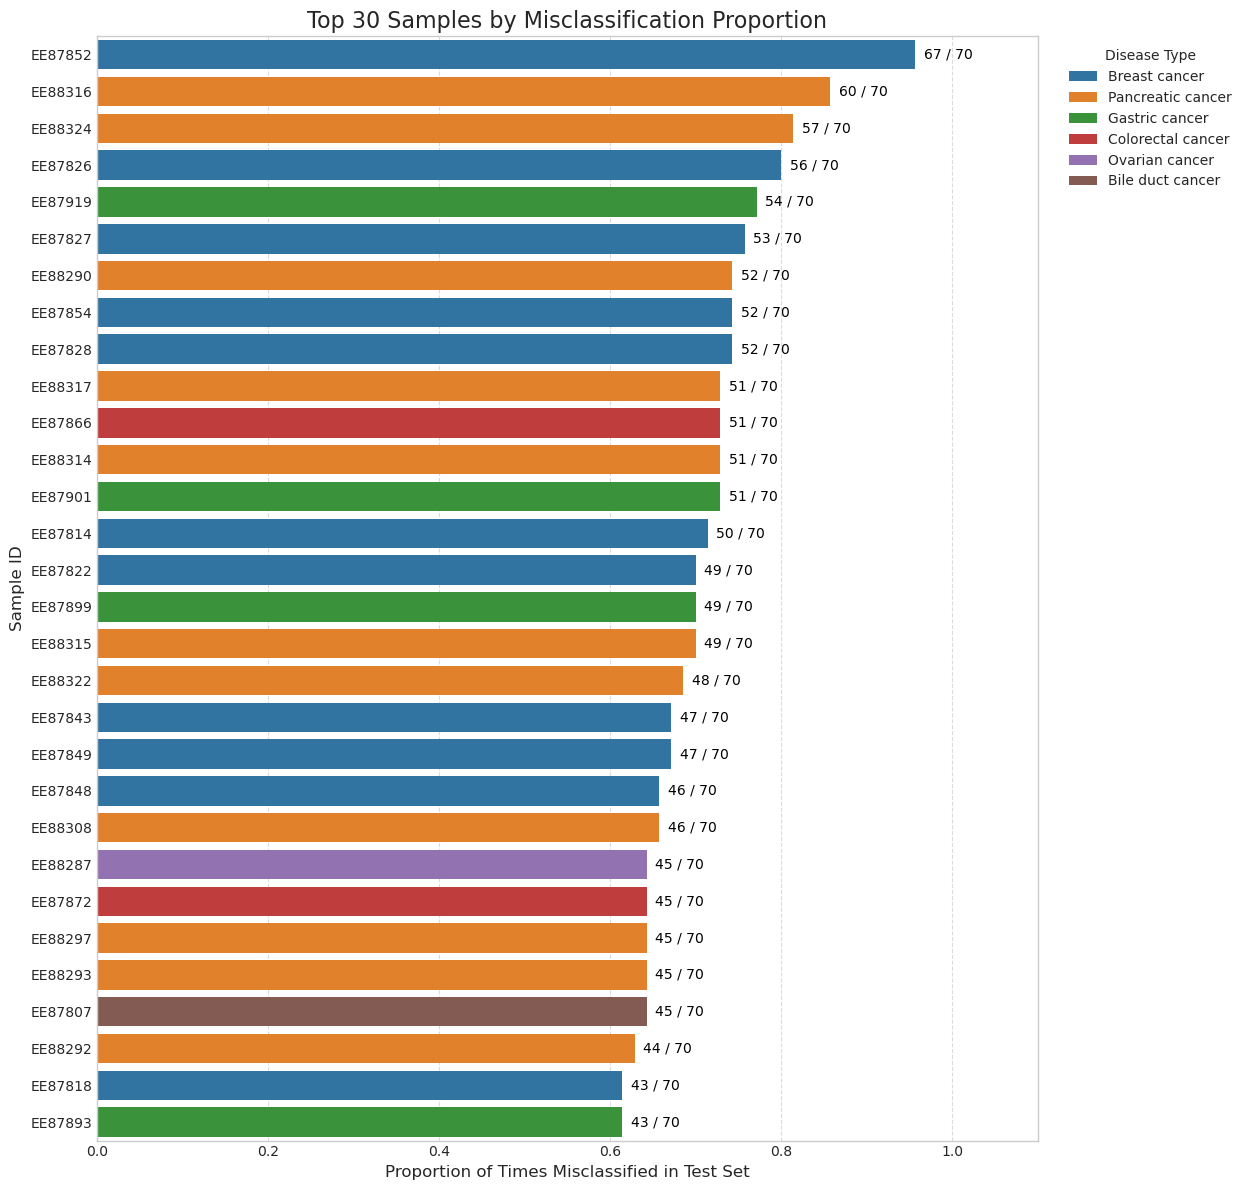


Disease Distribution in Top Misclassified Samples:
disease
Breast cancer        11
Pancreatic cancer    11
Gastric cancer        4
Colorectal cancer     2
Ovarian cancer        1
Bile duct cancer      1
Name: count, dtype: int64

Total Disease Distribution in Metadata:
disease
Healthy                    262
Lung cancer                 67
Breast cancer               54
Pancreatic cancer           35
Ovarian cancer              28
Colorectal cancer           27
Gastric cancer              27
Bile duct cancer            24
Lung cancer naive nsclc     12
Duodenal cancer              1
Name: count, dtype: int64

Proportion of Each Disease in Top Misclassified Samples:
disease
Breast cancer        0.366667
Pancreatic cancer    0.366667
Gastric cancer       0.133333
Colorectal cancer    0.066667
Ovarian cancer       0.033333
Bile duct cancer     0.033333
Name: count, dtype: float64

Proportion of Each Disease in Entire Metadata:
disease
Healthy                    0.487896
Lung cancer        

,ID,disease,misclassification_count,correct_classification_count,total_test_appearances,misclassification_proportion
0,EE87852,Breast cancer,67,3,70,0.957143
1,EE88316,Pancreatic cancer,60,10,70,0.857143
2,EE88324,Pancreatic cancer,57,13,70,0.814286
3,EE87826,Breast cancer,56,14,70,0.800000
4,EE87919,Gastric cancer,54,16,70,0.771429
5,EE87827,Breast cancer,53,17,70,0.757143
6,EE88290,Pancreatic cancer,52,18,70,0.742857
7,EE87854,Breast cancer,52,18,70,0.742857
8,EE87828,Breast cancer,52,18,70,0.742857
9,EE88317,Pancreatic cancer,51,19,70,0.728571


array(['EE87852', 'EE88316', 'EE88324', 'EE87826', 'EE87919', 'EE87827',
       'EE88290', 'EE87854', 'EE87828', 'EE88317', 'EE87866', 'EE88314',
       'EE87901', 'EE87814', 'EE87822', 'EE87899', 'EE88315', 'EE88322',
       'EE87843', 'EE87849', 'EE87848', 'EE88308', 'EE88287', 'EE87872',
       'EE88297', 'EE88293', 'EE87807', 'EE88292', 'EE87818', 'EE87893'],
      dtype=object)

In [29]:
from collections import Counter

import pandas as pd


def plot_misclassification_proportions(results_df: pd.DataFrame, metadata_df: pd.DataFrame, top_n: int = 25):
    """
    Analyzes and plots the proportion of times each sample was misclassified.

    Args:
        results_df: The DataFrame containing results from all experiments.
                    Must include 'misclassified_sample_ids' and 'test_sample_ids'.
        metadata_df: The DataFrame with sample metadata.
        top_n: The number of top misclassified samples to display.
    """
    if "test_sample_ids" not in results_df.columns:
        print("Error: 'test_sample_ids' column not found in results.")
        print("Please update your model_hpc.py script to save the test sample IDs for each fold and rerun your experiments.")
        return None

    # 1. Aggregate and count all misclassified IDs and all test set appearances
    all_misclassified = results_df["misclassified_sample_ids"].explode().dropna().tolist()
    all_test_appearances = results_df["test_sample_ids"].explode().dropna().tolist()

    if not all_misclassified:
        print("No misclassified samples found to analyze.")
        return None

    misclass_counts = Counter(all_misclassified)
    test_appearance_counts = Counter(all_test_appearances)

    # 2. Create a DataFrame with counts and proportions
    misclass_df = pd.DataFrame(misclass_counts.items(), columns=["ID", "misclassification_count"])
    appearance_df = pd.DataFrame(test_appearance_counts.items(), columns=["ID", "total_test_appearances"])

    # Merge the two counts dataframes
    stats_df = pd.merge(misclass_df, appearance_df, on="ID", how="left")

    # Calculate proportions and correct counts
    stats_df["misclassification_proportion"] = stats_df["misclassification_count"] / stats_df["total_test_appearances"]
    stats_df["correct_classification_count"] = stats_df["total_test_appearances"] - stats_df["misclassification_count"]

    # 3. Merge with metadata to get disease type
    merged_df = pd.merge(stats_df, metadata_df[["ID", "disease"]], on="ID", how="left")

    # 4. Prepare data for plotting
    plot_data = merged_df.sort_values("misclassification_proportion", ascending=False).head(top_n)

    # 5. Visualize the distribution
    plt.figure(figsize=(14, 12))
    barplot = sns.barplot(x="misclassification_proportion", y="ID", hue="disease", data=plot_data, dodge=False)

    # Add text annotations with the raw counts
    for index, row in plot_data.iterrows():
        barplot.text(
            row.misclassification_proportion + 0.01,  # position text slightly to the right of the bar
            barplot.get_yticks()[plot_data.index.get_loc(index)],  # get the y position of the bar
            f"{int(row.misclassification_count)} / {int(row.total_test_appearances)}",
            color="black",
            ha="left",
            va="center",
        )

    plt.title(f"Top {top_n} Samples by Misclassification Proportion", fontsize=16)
    plt.xlabel("Proportion of Times Misclassified in Test Set", fontsize=12)
    plt.ylabel("Sample ID", fontsize=12)
    plt.xlim(0, 1.1)  # Extend x-axis to make space for text
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.legend(title="Disease Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make space for legend
    plt.show()

    # Print the distribution of diseases in the top misclassified samples
    disease_distribution = plot_data["disease"].value_counts()
    print("\nDisease Distribution in Top Misclassified Samples:")
    print(disease_distribution)

    # What is the total distribution of diseases in the entire metadata?
    total_disease_distribution = metadata_df["disease"].value_counts()
    print("\nTotal Disease Distribution in Metadata:")
    print(total_disease_distribution)

    # Print the proportion of each disease in the top misclassified samples
    print("\nProportion of Each Disease in Top Misclassified Samples:")
    top_disease_proportions = disease_distribution / disease_distribution.sum()
    print(top_disease_proportions)
    print("\nProportion of Each Disease in Entire Metadata:")
    total_disease_proportions = total_disease_distribution / total_disease_distribution.sum()
    print(total_disease_proportions)

    # Display the detailed statistics table for the top N samples
    print("\nDetailed Misclassification Statistics (Top Samples):")
    display(plot_data[["ID", "disease", "misclassification_count", "correct_classification_count", "total_test_appearances", "misclassification_proportion"]].reset_index(drop=True))

    # Return the DataFrame for further analysis if needed
    return plot_data["ID"].values


# --- Example Usage ---
# Ensure 'all_results_df' and 'cris_metadata' are loaded
misclassification_df = plot_misclassification_proportions(all_results_df, cris_metadata, top_n=30)
misclassification_df

/tmp/ipykernel_2399/4197340385.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', num_colors)


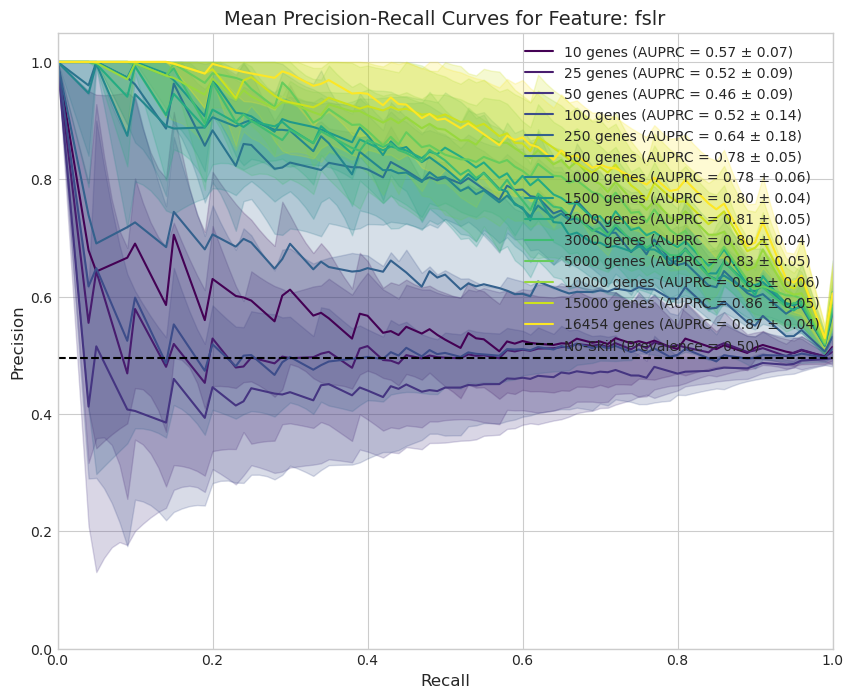

/tmp/ipykernel_2399/4197340385.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', num_colors)


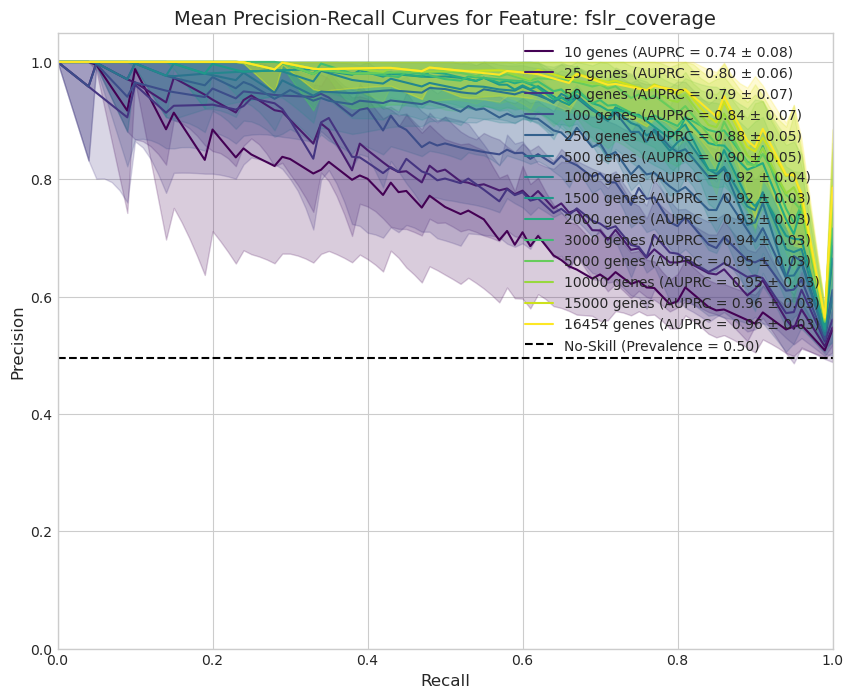

/tmp/ipykernel_2399/4197340385.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', num_colors)


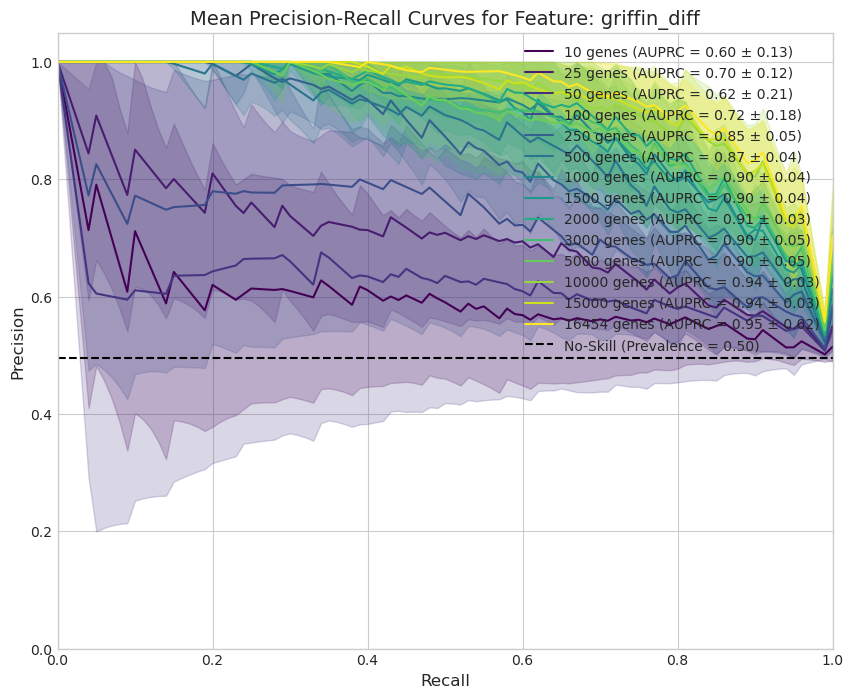

/tmp/ipykernel_2399/4197340385.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', num_colors)


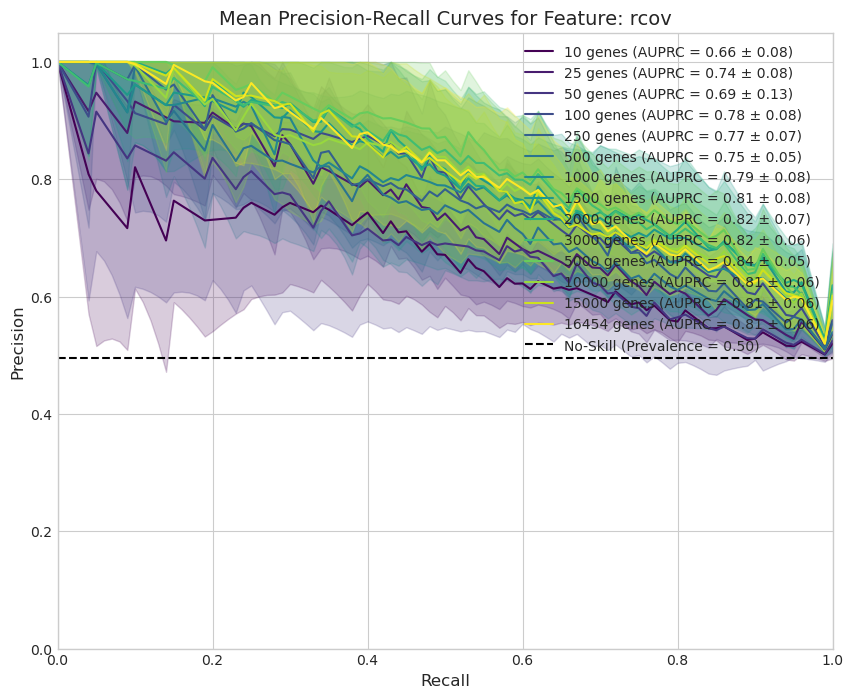

/tmp/ipykernel_2399/4197340385.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', num_colors)


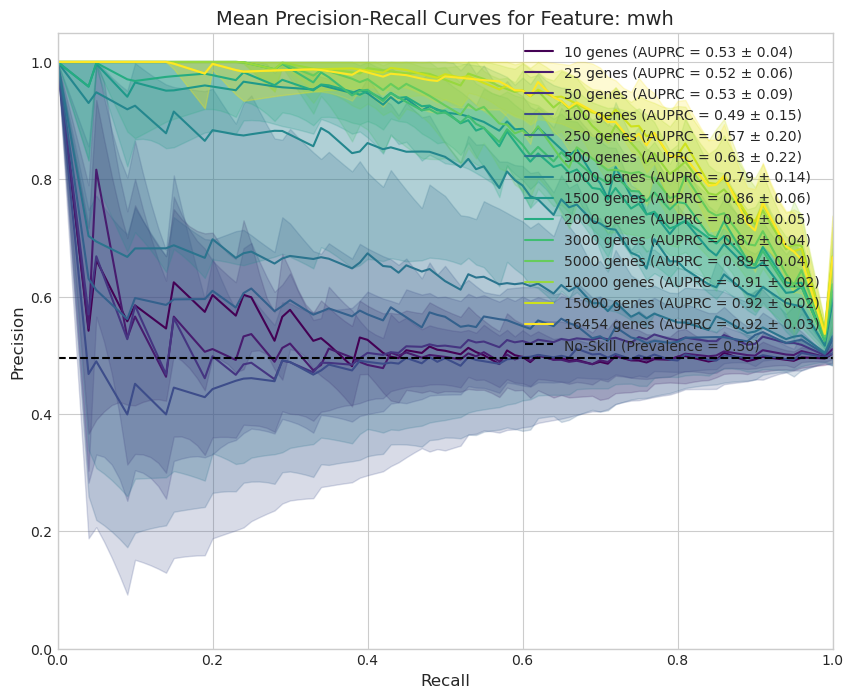

In [30]:
def plot_mean_pr_curves_by_gene_count(results_df: pd.DataFrame, feature_name: str):
    """
    Plots the mean Precision-Recall (PR) curves for a given feature,
    grouped by the number of top genes, using the viridis colormap.

    Args:
        results_df: The DataFrame containing the results from all experiments.
        feature_name: The specific feature (e.g., 'fslr_coverage') to plot.
    """

    # Filter the results for the specific feature
    feature_df = results_df[results_df["feature"] == feature_name].copy()

    if feature_df.empty:
        print(f"No results found for feature: {feature_name}")
        return

    # Create a base for interpolation (common recall axis)
    base_recall = np.linspace(0, 1, 101)

    plt.figure(figsize=(10, 8))

    # Get the unique values for 'top_genes' and sort them
    top_genes_values = sorted(feature_df["top_genes"].unique())
    num_colors = len(top_genes_values)
    colors = cm.get_cmap("viridis", num_colors)

    for i, n_genes in enumerate(top_genes_values):
        # Get all folds for this specific gene count
        group = feature_df[feature_df["top_genes"] == n_genes]

        precision_list = []
        auprc_scores = []

        for _, row in group.iterrows():
            # Ensure recall values are sorted for interpolation and AUC calculation
            recall_sorted, precision_sorted = zip(*sorted(zip(row["recall_full_model"], row["precision_full_model"], strict=False)), strict=False)

            # Interpolate precision onto the base recall grid
            interp_func = interp1d(recall_sorted, precision_sorted, kind="linear")
            precision_list.append(interp_func(base_recall))

            # Calculate Area Under PR Curve (AUPRC)
            auprc_scores.append(auc(recall_sorted, precision_sorted))

        # Calculate mean and std deviation of precisions and AUPRCs
        mean_precisions = np.mean(precision_list, axis=0)
        mean_auprc = np.mean(auprc_scores)
        std_auprc = np.std(auprc_scores)

        # Get the color for the current line
        color = colors(i / (num_colors - 1) if num_colors > 1 else 0)

        # Plot the mean PR curve
        plt.plot(base_recall, mean_precisions, color=color, label=f"{n_genes} genes (AUPRC = {mean_auprc:.2f} ± {std_auprc:.2f})")

        # Optional: Add a shaded region for standard deviation
        std_precisions = np.std(precision_list, axis=0)
        precisions_upper = np.minimum(mean_precisions + std_precisions, 1)
        precisions_lower = np.maximum(mean_precisions - std_precisions, 0)
        plt.fill_between(base_recall, precisions_lower, precisions_upper, color=color, alpha=0.2)

    # Add a no-skill line (proportion of the positive class)
    positive_ratio = 207 / (211 + 207)
    plt.plot([0, 1], [positive_ratio, positive_ratio], "k--", label=f"No-Skill (Prevalence = {positive_ratio:.2f})")

    # Final plot formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title(f"Mean Precision-Recall Curves for Feature: {feature_name}", fontsize=14)
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()


# Call the function for a specific feature
# Make sure 'all_results_df' is loaded from your .pkl files
plot_mean_pr_curves_by_gene_count(all_results_df, feature_name="fslr")
plot_mean_pr_curves_by_gene_count(all_results_df, feature_name="fslr_coverage")
plot_mean_pr_curves_by_gene_count(all_results_df, feature_name="griffin_diff")
plot_mean_pr_curves_by_gene_count(all_results_df, feature_name="rcov")
plot_mean_pr_curves_by_gene_count(all_results_df, feature_name="mwh")

/tmp/ipykernel_2399/4122118923.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', num_colors)


--- Curve Points for 16454 Genes ---
Recall | Precision
-------|-----------
 0.000 |  1.0000
 0.010 |  0.9950
 0.020 |  0.9900
 0.030 |  0.9850
 0.040 |  0.9800
 0.050 |  0.9750
 0.060 |  0.9700
 0.070 |  0.9650
 0.080 |  0.9600
 0.090 |  0.9550
 0.100 |  0.9500
 0.110 |  0.9450
 0.120 |  0.9400
 0.130 |  0.9350
 0.140 |  0.9300
 0.150 |  0.9250
 0.160 |  0.9200
 0.170 |  0.9150
 0.180 |  0.9100
 0.190 |  0.9050
 0.200 |  1.0000
 0.210 |  0.9958
 0.220 |  0.9917
 0.230 |  0.9875
 0.240 |  0.9833
 0.250 |  0.9792
 0.260 |  0.9750
 0.270 |  0.9708
 0.280 |  0.9667
 0.290 |  0.9625
 0.300 |  0.9583
 0.310 |  0.9542
 0.320 |  0.9500
 0.330 |  0.9458
 0.340 |  0.9417
 0.350 |  0.9375
 0.360 |  0.9333
 0.370 |  0.9292
 0.380 |  0.9250
 0.390 |  0.9208
 0.400 |  0.9333
 0.410 |  0.9288
 0.420 |  0.9243
 0.430 |  0.9198
 0.440 |  0.9153
 0.450 |  0.9108
 0.460 |  0.9063
 0.470 |  0.9018
 0.480 |  0.8973
 0.490 |  0.8928
 0.500 |  0.8883
 0.510 |  0.8806
 0.520 |  0.8729
 0.530 |  0.8652
 0.540

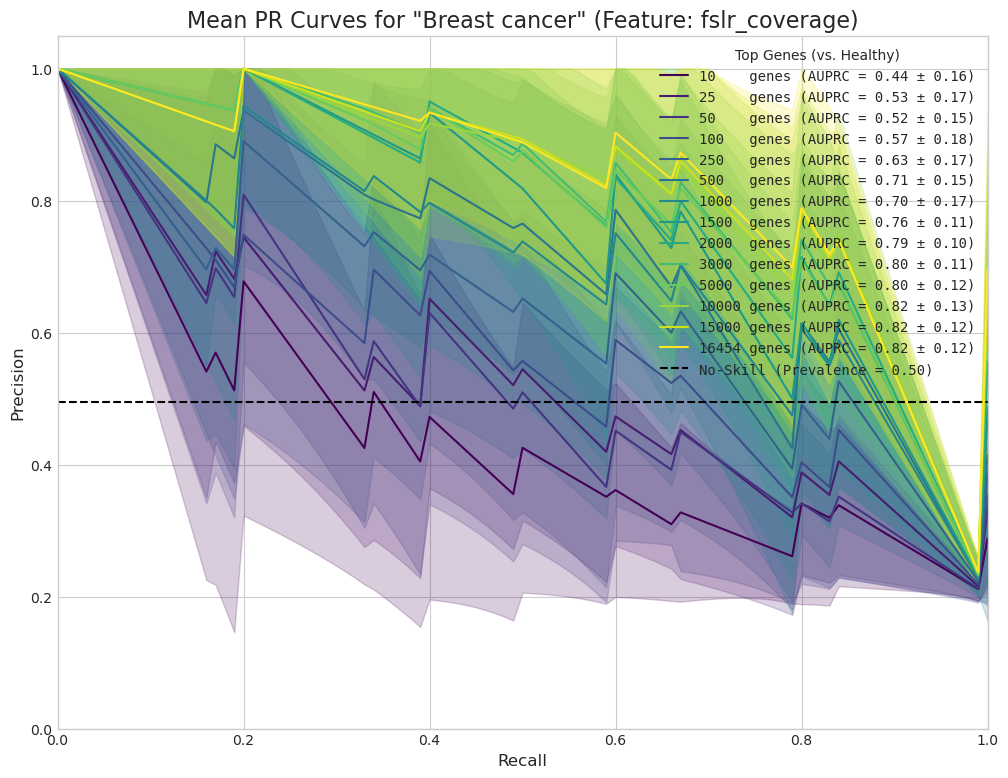

In [ ]:
def plot_mean_pr_curves_by_cancer_type(results_df: pd.DataFrame, feature_name: str, cancer_type: str, classifier_name: str = "Support Vector Machine"):
    """
    Plots the mean Precision-Recall (PR) curves for a specific feature, classifier, and cancer type,
    with a color gradient for the number of genes.
    """

    # Filter for the specific feature and classifier
    feature_df = results_df[(results_df["feature"] == feature_name) & (results_df["classifier"] == classifier_name)].copy()

    if feature_df.empty:
        print(f"No results found for feature '{feature_name}' and classifier '{classifier_name}'")
        return

    # Create a base for interpolation (common recall axis)
    base_recall = np.linspace(0, 1, 101)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 9))

    top_genes_values = sorted(feature_df["top_genes"].unique())

    # --- FIX IS HERE ---
    # Define num_colors before using it
    num_colors = len(top_genes_values)

    cmap = cm.get_cmap("viridis", num_colors)

    for i, n_genes in enumerate(top_genes_values):
        group = feature_df[feature_df["top_genes"] == n_genes]

        precision_list, auprc_scores = [], []

        for _, row in group.iterrows():
            # Check if this cancer type was present in this fold's test set
            if cancer_type in row["pr_per_cancer_type"]:
                # Access the nested dictionary for the specific cancer type
                pr_data = row["pr_per_cancer_type"][cancer_type]

                # Sort by recall for interpolation and AUC calculation
                recall_sorted, precision_sorted = zip(*sorted(zip(pr_data["recall"], pr_data["precision"], strict=False)), strict=False)

                # Interpolate precision values onto the base recall grid
                interp_func = interp1d(recall_sorted, precision_sorted, kind="linear")
                precision_list.append(interp_func(base_recall))

                # Calculate the Area Under the PR Curve (AUPRC)
                auprc_scores.append(auc(recall_sorted, precision_sorted))

        # If no data was found for this gene count, skip
        if not precision_list:
            continue

        mean_precisions = np.mean(precision_list, axis=0)
        mean_auprc, std_auprc = np.mean(auprc_scores), np.std(auprc_scores)

        # --- NEW: Print the data points for the specified curve ---
        if n_genes == top_genes_values[-1]:
            print(f"--- Curve Points for {n_genes} Genes ---")
            print("Recall | Precision")
            print("-------|-----------")
            for rec, pre in zip(base_recall, mean_precisions, strict=False):
                print(f" {rec:5.3f} |  {pre:6.4f}")
            print("---------------------------------")

        color = cmap(i / (num_colors - 1) if num_colors > 1 else 0)

        # Create a padded string for the legend label
        label_text = f"{n_genes:<5} genes (AUPRC = {mean_auprc:.2f} ± {std_auprc:.2f})"

        ax.plot(base_recall, mean_precisions, label=label_text, color=color)

        std_precisions = np.std(precision_list, axis=0)
        precisions_upper = np.minimum(mean_precisions + std_precisions, 1)
        precisions_lower = np.maximum(mean_precisions - std_precisions, 0)

        ax.fill_between(base_recall, precisions_lower, precisions_upper, color=color, alpha=0.2)

    mono_font = FontProperties(family="monospace")

    # Add a no-skill line (hardcoded as requested)
    positive_ratio = 207 / (211 + 207)
    ax.plot([0, 1], [positive_ratio, positive_ratio], "k--", label=f"No-Skill (Prevalence = {positive_ratio:.2f})")

    # Final plot formatting
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f'Mean PR Curves for "{cancer_type}" (Feature: {feature_name})', fontsize=16)
    ax.grid(True)

    ax.legend(loc="upper right", prop=mono_font, title="Top Genes (vs. Healthy)")

    plt.show()


# --- Example Usage ---

# This map helps translate short names to the full names in your dataframe
CANCER_MAP = {"breast": "Breast cancer", "bileduct": "Bile duct cancer", "colorectal": "Colorectal cancer", "gastric": "Gastric cancer", "lung": "Lung cancer naive nsclc", "ovarian": "Ovarian cancer", "pancreatic": "Pancreatic cancer"}

# Ensure your 'all_results_df' is loaded before running this.
# Plot the PR curves specifically for Breast Cancer using the 'fslr_coverage' feature.
if "all_results_df" in locals() and CANCER_MAP["breast"] in all_results_df["pr_per_cancer_type"].iloc[0]:
    plot_mean_pr_curves_by_cancer_type(all_results_df, feature_name="fslr_coverage", cancer_type=CANCER_MAP["breast"])
else:
    print("Please load 'all_results_df' and ensure it contains data for 'Breast cancer'.")

Aggregated Results Ready for Plotting:
  feature  top_genes  mean_auc   std_auc  mean_recall  std_recall  \
0    fslr         10  0.541863  0.100848     0.389762    0.289185   
1    fslr         25  0.486068  0.151119     0.232381    0.307204   
2    fslr         50  0.392809  0.140454     0.073333    0.155397   
3    fslr        100  0.452087  0.200481     0.188810    0.285322   
4    fslr        250  0.605225  0.246229     0.487857    0.341381   

   mean_precision  std_precision  mean_f1_score  std_f1_score  
0        0.398558       0.280002       0.392103      0.281194  
1        0.239899       0.316637       0.233292      0.304702  
2        0.127143       0.269748       0.092220      0.194469  
3        0.285802       0.387039       0.199854      0.289020  
4        0.472717       0.329772       0.477567      0.330957  


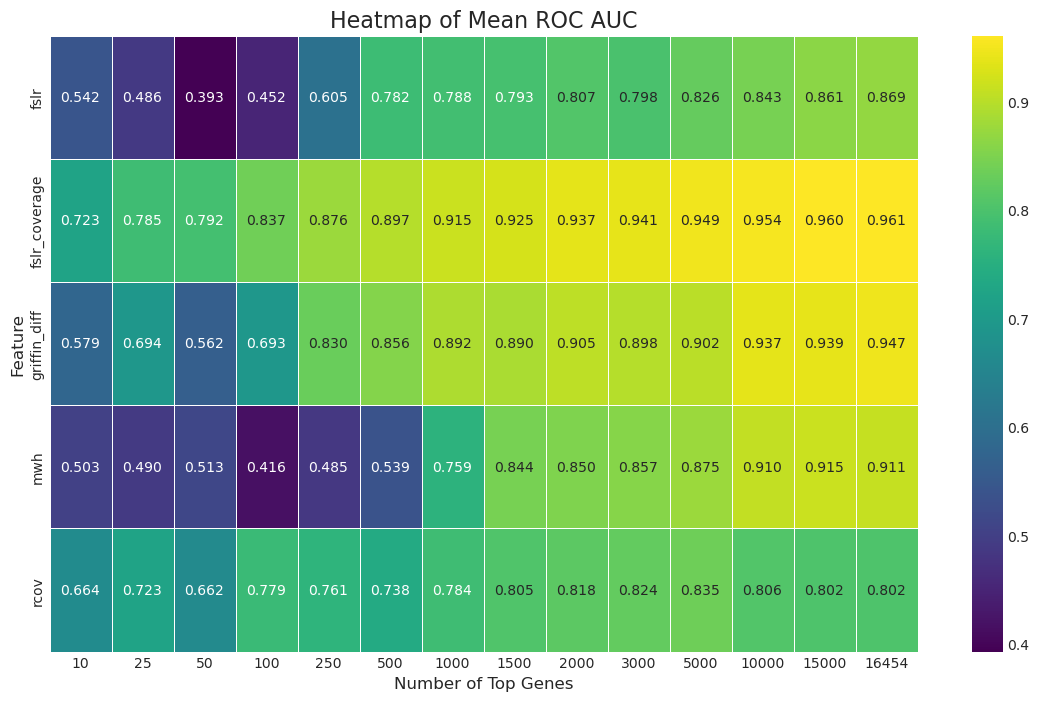

In [31]:
# --- Extract nested metrics from the classification report ---
def extract_metrics(df):
    # Safely extract metrics for class '1' (the cancer class)
    df["recall_cancer"] = df["classification_report_full_model"].apply(lambda x: x.get("1", {}).get("recall"))
    df["precision_cancer"] = df["classification_report_full_model"].apply(lambda x: x.get("1", {}).get("precision"))
    df["f1_score_cancer"] = df["classification_report_full_model"].apply(lambda x: x.get("1", {}).get("f1-score"))
    return df


all_results_df = extract_metrics(all_results_df)

# --- Aggregate results by data combination ---
# Calculate the mean and std dev across folds for each unique experiment
agg_results = all_results_df.groupby(["feature", "top_genes"]).agg(mean_auc=("auc_full_model", "mean"), std_auc=("auc_full_model", "std"), mean_recall=("recall_cancer", "mean"), std_recall=("recall_cancer", "std"), mean_precision=("precision_cancer", "mean"), std_precision=("precision_cancer", "std"), mean_f1_score=("f1_score_cancer", "mean"), std_f1_score=("f1_score_cancer", "std")).reset_index()

print("Aggregated Results Ready for Plotting:")
print(agg_results.head())

# Pivot the data to create a matrix for the heatmap
heatmap_data = agg_results.pivot(index="feature", columns="top_genes", values="mean_auc")

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,  # Display the AUC values on the cells
    fmt=".3f",  # Format the numbers to 3 decimal places
    cmap="viridis",  # Color map
    linewidths=0.5,
)

plt.title("Heatmap of Mean ROC AUC", fontsize=16)
plt.xlabel("Number of Top Genes", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.show()

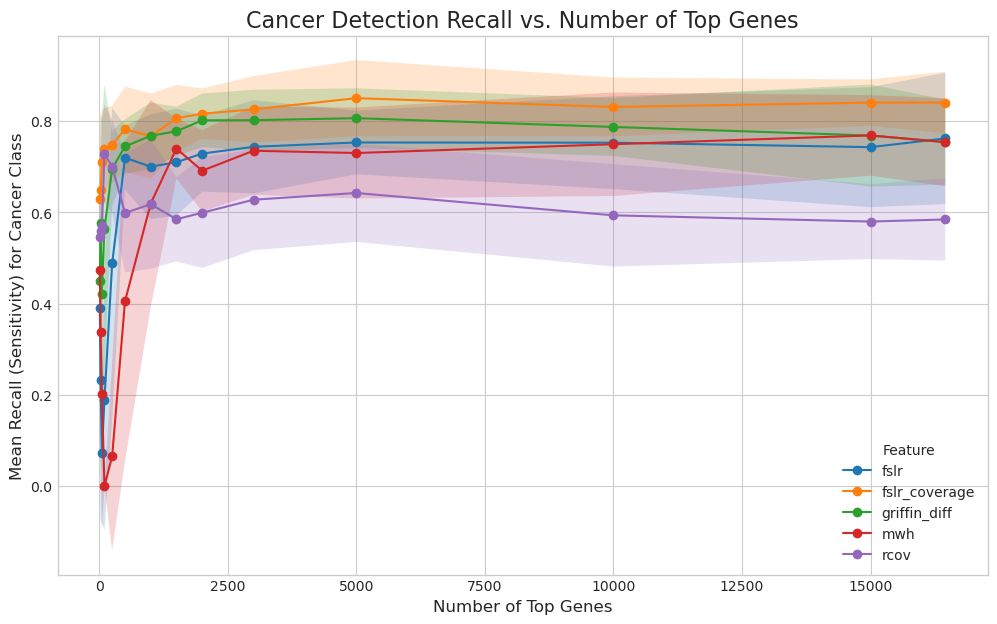

In [32]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Get a list of the features to plot
features = agg_results["feature"].unique()

for feature in features:
    subset = agg_results[agg_results["feature"] == feature]
    ax.plot(subset["top_genes"], subset["mean_recall"], marker="o", linestyle="-", label=feature)
    ax.fill_between(subset["top_genes"], subset["mean_recall"] - subset["std_recall"], subset["mean_recall"] + subset["std_recall"], alpha=0.2)

ax.set_title("Cancer Detection Recall vs. Number of Top Genes", fontsize=16)
ax.set_xlabel("Number of Top Genes", fontsize=12)
ax.set_ylabel("Mean Recall (Sensitivity) for Cancer Class", fontsize=12)
ax.legend(title="Feature")
# ax.set_xscale('log') # Use a log scale if you have a wide range of gene counts
plt.show()

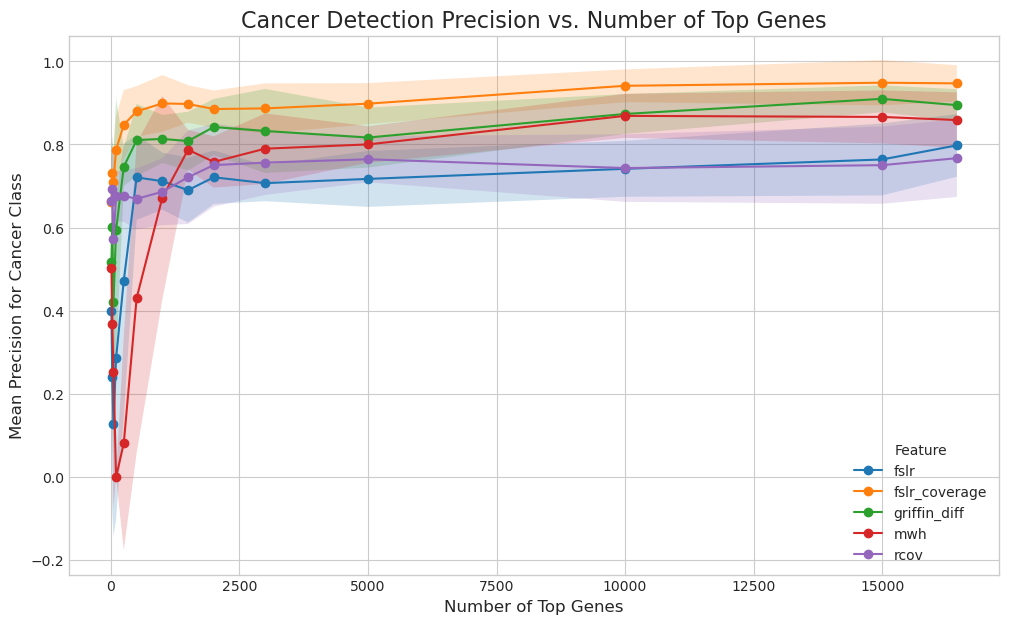

In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

for feature in features:
    subset = agg_results[agg_results["feature"] == feature]
    ax.plot(subset["top_genes"], subset["mean_precision"], marker="o", linestyle="-", label=feature)
    ax.fill_between(subset["top_genes"], subset["mean_precision"] - subset["std_precision"], subset["mean_precision"] + subset["std_precision"], alpha=0.2)

ax.set_title("Cancer Detection Precision vs. Number of Top Genes", fontsize=16)
ax.set_xlabel("Number of Top Genes", fontsize=12)
ax.set_ylabel("Mean Precision for Cancer Class", fontsize=12)
ax.legend(title="Feature")
plt.show()

/tmp/ipykernel_526290/2933587004.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_526290/2933587004.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


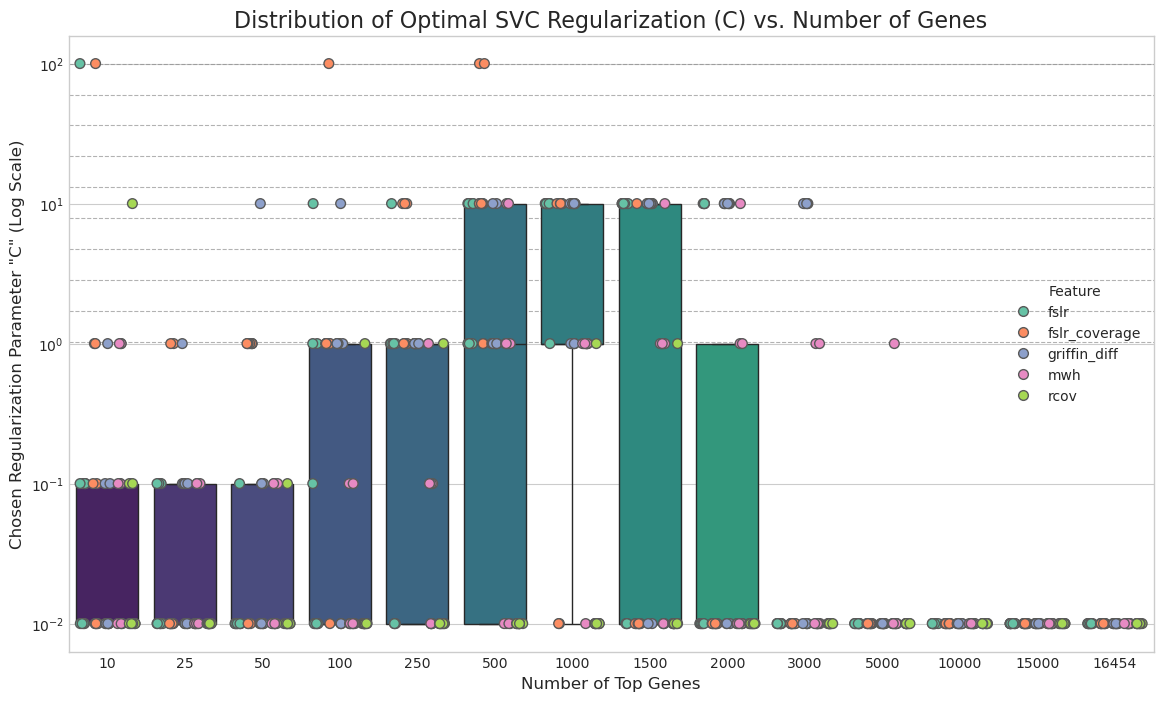

In [14]:
# --- 1. Prepare the Data (same as before) ---
# Ensure all_results_df is loaded from your experiment
svm_results_df = all_results_df[all_results_df["classifier"] == "Support Vector Machine"].copy()
svm_results_df["best_C"] = svm_results_df["best_params"].apply(lambda params: params["clf__C"])

# --- 2. Create the Enhanced Plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Define the exact C values that were used in the grid search
c_options = np.logspace(0.01, 2, 10)

# Add horizontal lines to show the available C options
for c_val in c_options:
    ax.axhline(c_val, ls="--", color="gray", alpha=0.6, linewidth=0.8)

# Create a boxplot, treating 'top_genes' as a categorical variable
sns.boxplot(
    data=svm_results_df,
    x="top_genes",
    y="best_C",
    palette="viridis",
    ax=ax,
    fliersize=0,  # Hide outlier markers, since the stripplot will show all points
)

# --- ✨ MODIFIED: Overlay a stripplot with colors based on 'feature' ---
sns.stripplot(
    data=svm_results_df,
    x="top_genes",
    y="best_C",
    ax=ax,
    hue="feature",  # Use the 'feature' column to assign colors
    palette="Set2",  # A good categorical color palette
    jitter=0.2,  # Add jitter to prevent points from overlapping
    size=7,
    dodge=True,  # Separate the points for each feature
    linewidth=1,
    edgecolor="gray",
)

# --- 3. Formatting ---
ax.set_yscale("log")
ax.set_title("Distribution of Optimal SVC Regularization (C) vs. Number of Genes", fontsize=16)
ax.set_xlabel("Number of Top Genes", fontsize=12)
ax.set_ylabel('Chosen Regularization Parameter "C" (Log Scale)', fontsize=12)

# The legend is now automatically created by the 'hue' parameter
# We can customize its title
handles, labels = ax.get_legend_handles_labels()
# The number of features will determine how many legend entries we show
num_features = len(svm_results_df["feature"].unique())
ax.legend(handles[:num_features], labels[:num_features], title="Feature")

plt.show()

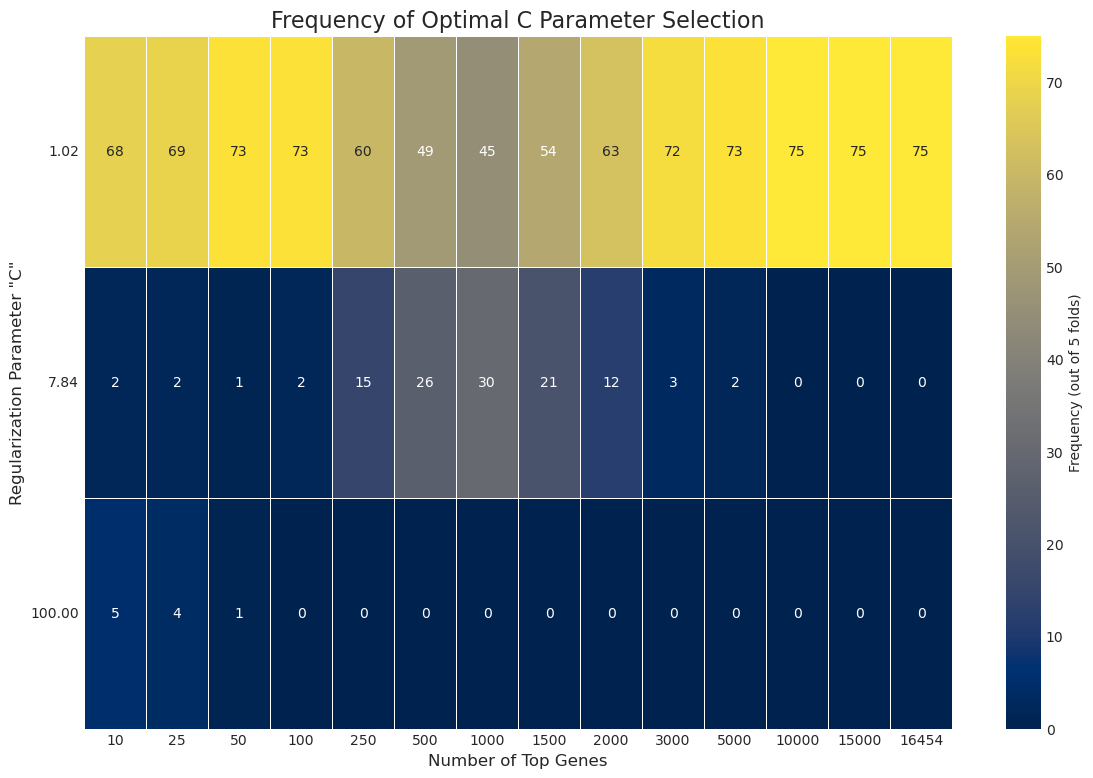

In [15]:
# --- 1. Calculate the frequency of each C value being chosen ---
# First, we need to map the exact 'best_C' float values to the closest option from our c_options grid
# This handles tiny floating point inaccuracies
def map_to_closest(value, options):
    return options[np.abs(options - value).argmin()]


svm_results_df["best_C_approx"] = svm_results_df["best_C"].apply(lambda c: map_to_closest(c, c_options))

# Group by genes and C value and count the occurrences
frequency_df = svm_results_df.groupby(["top_genes", "best_C_approx"]).size().reset_index(name="count")

# --- 2. Create the Heatmap ---
# Pivot the data into a matrix format suitable for a heatmap
heatmap_pivot = frequency_df.pivot(index="best_C_approx", columns="top_genes", values="count").fillna(0)

plt.figure(figsize=(14, 9))
sns.heatmap(
    heatmap_pivot,
    annot=True,  # Show the counts in each cell
    fmt=".0f",  # Format as an integer
    cmap="cividis",  # A perception-friendly color map
    linewidths=0.5,
    cbar_kws={"label": "Frequency (out of 5 folds)"},  # Label for the color bar
)

# --- 3. Formatting ---
plt.title("Frequency of Optimal C Parameter Selection", fontsize=16)
plt.xlabel("Number of Top Genes", fontsize=12)
plt.ylabel('Regularization Parameter "C"', fontsize=12)
# Format Y-axis labels to be more readable
plt.yticks(rotation=0)
plt.gca().set_yticklabels([f"{val:.2f}" for val in heatmap_pivot.index])
plt.show()